Project 1: See if the stock market return affects the total amount in accounts

In [7]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
file = '../Work onCleaning and Combining the Datasets/Filtered Data with Subtypes.xlsx'
df = pd.read_excel(file)
df.columns

Index(['ein', 'Year', 'Accounts', 'Contributions', 'Grants', 'Assets', 'Type',
       'subtype'],
      dtype='object')

Step 1: Find total assets for each year

In [9]:
#sum the account columns for each year
df_2024 = df[df['Year'] == 2024]
total_2024 = df_2024["Assets"].sum()
print("Total 2024 Assets:", total_2024)

df_2023 = df[df['Year'] == 2023]
total_2023 = df_2023["Assets"].sum()
print("Total 2023 Assets:", total_2023)

df_2022 = df[df['Year'] == 2022]
total_2022 = df_2022["Assets"].sum()
print("Total 2022 Assets:", total_2022)

df_2021 = df[df['Year'] == 2021]
total_2021 = df_2021["Assets"].sum()
print("Total 2021 Assets:", total_2021)

df_2020 = df[df['Year'] == 2020]
total_2020 = df_2020["Assets"].sum()
print("Total 2020 Assets:", total_2020)

df_2019 = df[df['Year'] == 2019]
total_2019 = df_2019["Assets"].sum()
print("Total 2019 Assets:", total_2019)

df_2018 = df[df['Year'] == 2018]
total_2018 = df_2018["Assets"].sum()
print("Total 2018 Assets:", total_2018)

df_2017 = df[df['Year'] == 2017]
total_2017 = df_2017["Assets"].sum()

df_2016 = df[df['Year'] == 2016]
total_2016 = df_2016["Assets"].sum()

df_2015 = df[df['Year'] == 2015]
total_2015 = df_2015["Assets"].sum()

df_2014 = df[df['Year'] == 2014]
total_2014 = df_2014["Assets"].sum()

print("Percent change 2023 to 2024:", ((total_2024-total_2023)/total_2023)*100, "  market change is 23.31%")
print("Percent change 2022 to 2023:", ((total_2023-total_2022)/total_2022)*100, "  market change is 24.23%")
print("Percent change 2021 to 2022:", ((total_2022-total_2021)/total_2021)*100, "   market change is -19.44%")
print("Percent change 2020 to 2021:", ((total_2021-total_2020)/total_2020)*100, "   market change is 26.89%")
print("Percent change 2019 to 2020:", ((total_2020-total_2019)/total_2019)*100, "    market change is 16.26%")
print("Percent change 2018 to 2019:", ((total_2019-total_2018)/total_2018)*100, "   market change is 28.88%")
print("Percent change 2017 to 2018:", ((total_2018-total_2017)/total_2017)*100, "  market change is -6.24%")
print("Percent change 2016 to 2017:", ((total_2017-total_2016)/total_2016)*100, "  market change is 19.42%")
print("Percent change 2015 to 2016:", ((total_2016-total_2015)/total_2015)*100, "  market change is 9.54%")
print("Percent change 2014 to 2015:", ((total_2015-total_2014)/total_2014)*100, "  market change is -0.73%")


Total 2024 Assets: 205845008957.0
Total 2023 Assets: 200596336329.0
Total 2022 Assets: 181203675778.0
Total 2021 Assets: 180253581156.0
Total 2020 Assets: 128465694076.0
Total 2019 Assets: 115687450085.0
Total 2018 Assets: 96399465325.0
Percent change 2023 to 2024: 2.6165346406883527   market change is 23.31%
Percent change 2022 to 2023: 10.702134196636683   market change is 24.23%
Percent change 2021 to 2022: 0.527087792601326    market change is -19.44%
Percent change 2020 to 2021: 40.31261999749319    market change is 26.89%
Percent change 2019 to 2020: 11.0454884964716     market change is 16.26%
Percent change 2018 to 2019: 20.00839392103755    market change is 28.88%
Percent change 2017 to 2018: 10.082423470757178   market change is -6.24%
Percent change 2016 to 2017: 32.025981459606726   market change is 19.42%
Percent change 2015 to 2016: 13.191488488949501   market change is 9.54%
Percent change 2014 to 2015: 12.372638602540901   market change is -0.73%


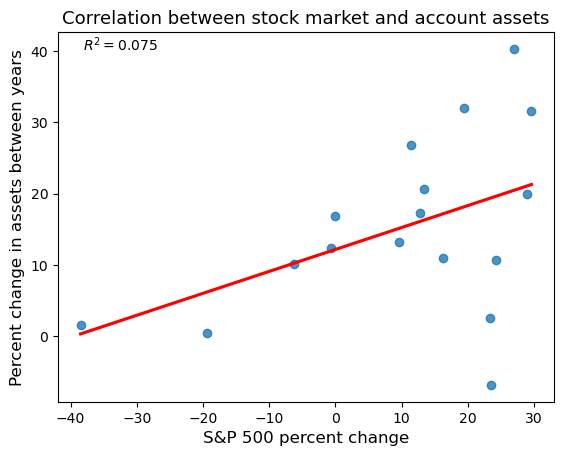

In [10]:
from sklearn.metrics import r2_score

mkt = [23.31,24.23,-19.44,26.89,16.26,28.88,-6.24,19.42,9.54,-0.73, 11.39, 29.6, 13.41, 0, 12.78, 23.45, -38.49, 3.53]
mkt = mkt[::-1]
#pct_cng = [2.6165346406883527, 10.702134196636683,0.527087792601326,40.31261999749319,11.0454884964716,20.00839392103755,10.082423470757178,32.025981459606726,13.191488488949501,12.372638602540901]
pct_cng = []
totals = []

# creates a list with the total amount in accounts for every year, [0] = 2007
for i in range(len(mkt)):
  df2 = df[df['Year'] == (2007 + i)]
  total_df2 = df2["Assets"].sum()
  totals.append(float(total_df2))

# finding the percent change between each year
for i in range(len(mkt)):
  if i == 17:
    pass
  else:
    pct_cng.append(float(((totals[i+1]-totals[i])/totals[i])*100))


#actual data, values from your regression model
r_squared = r2_score(mkt[1:], pct_cng)

# graphing
sns.regplot(x=mkt[1:], y=pct_cng, ci=None, line_kws={'color':'red'})

# Add labels and a title
plt.xlabel("S&P 500 percent change", fontsize = 12)
plt.ylabel("Percent change in assets between years", fontsize = 12)
plt.title("Correlation between stock market and account assets", fontsize = 13)

# Display the plot
plt.text(0.05, 0.95, f'$R^2 = {r_squared:.3f}$', transform=plt.gca().transAxes)
plt.show()